In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [46]:
import os

folder = r"C:\Users\jsart\Downloads\marketing_AB.csv"
print(os.listdir(folder))

['marketing_AB.csv']


In [26]:
df = pd.read_csv("C:/Users/jsart/Downloads/marketing_AB.csv/marketing_AB.csv")
df

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14
...,...,...,...,...,...,...,...
588096,588096,1278437,ad,False,1,Tuesday,23
588097,588097,1327975,ad,False,1,Tuesday,23
588098,588098,1038442,ad,False,3,Tuesday,23
588099,588099,1496395,ad,False,1,Tuesday,23


In [27]:
df.drop(columns = ['Unnamed: 0', 'user id'], inplace = True)
df

,test group,converted,total ads,most ads day,most ads hour
0,ad,False,130,Monday,20
1,ad,False,93,Tuesday,22
2,ad,False,21,Tuesday,18
3,ad,False,355,Tuesday,10
4,ad,False,276,Friday,14
...,...,...,...,...,...
588096,ad,False,1,Tuesday,23
588097,ad,False,1,Tuesday,23
588098,ad,False,3,Tuesday,23
588099,ad,False,1,Tuesday,23


In [28]:
df.shape

(588101, 5)

In [29]:
df.head(10)

,test group,converted,total ads,most ads day,most ads hour
0,ad,False,130,Monday,20
1,ad,False,93,Tuesday,22
2,ad,False,21,Tuesday,18
3,ad,False,355,Tuesday,10
4,ad,False,276,Friday,14
5,ad,False,734,Saturday,10
6,ad,False,264,Wednesday,13
7,ad,False,17,Sunday,18
8,ad,False,21,Tuesday,19
9,ad,False,142,Monday,14


In [30]:
df.dtypes

test group         str
converted         bool
total ads        int64
most ads day       str
most ads hour    int64
dtype: object

In [33]:
df.isna().sum()

test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

In [34]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
total ads,588101.0,24.820876,43.715181,1.0,4.0,13.0,27.0,2065.0
most ads hour,588101.0,14.469061,4.834634,0.0,11.0,14.0,18.0,23.0


In [59]:
unique_groups = df['test group'].unique()
print(unique_groups)
converted =df['converted'].unique()
print(converted)
most_add_day= df['most ads day'].unique()
print(most_add_day)


<StringArray>
['ad', 'psa']
Length: 2, dtype: str
[False  True]
<StringArray>
['Monday', 'Tuesday', 'Friday', 'Saturday', 'Wednesday', 'Sunday', 'Thursday']
Length: 7, dtype: str


In [60]:
df['converted'] = df['converted'].astype(int)
df.dtypes

Unnamed: 0       int64
user id          int64
test group         str
converted        int64
total ads        int64
most ads day       str
most ads hour    int64
dtype: object

In [64]:
# Statics T-test perform
control_group = df[df['test group'] == 'psa']
test_group = df[df['test group'] == 'ad']

t_stat, p_val = stats.ttest_ind(test_group['converted'], control_group['converted'])
print(f"Test Group Analysis - T-statistic: {t_stat}, P-value: {p_val}")

Test Group Analysis - T-statistic: 7.370405974285658, P-value: 1.703305262783145e-13


In [62]:
if p_val < 0.05:
    print("Reject the null hypothesis: There is a significant difference in conversion rates between the 'ad' and 'psa' groups.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in conversion rates between the 'ad' and 'psa' groups.")

Reject the null hypothesis: There is a significant difference in conversion rates between the 'ad' and 'psa' groups.


In [66]:
# Statics F anova one way perform Most add Day
anova_result_day = stats.f_oneway(
    df[df['most ads day'] == 'Monday']['converted'],
    df[df['most ads day'] == 'Tuesday']['converted'],
    df[df['most ads day'] == 'Wednesday']['converted'],
    df[df['most ads day'] == 'Thursday']['converted'],
    df[df['most ads day'] == 'Friday']['converted'],
    df[df['most ads day'] == 'Saturday']['converted'],
    df[df['most ads day'] == 'Sunday']['converted']
)
print(f"Most Ads Day Analysis - F-statistic: {anova_result_day.statistic}, P-value: {anova_result_day.pvalue}")

Most Ads Day Analysis - F-statistic: 68.38818386898397, P-value: 1.803200765751262e-85


In [65]:
if anova_result_day.pvalue < 0.05:
    print("Reject the null hypothesis: The day with the most ads seen significantly affects the conversion rate.")
else:
    print("Fail to reject the null hypothesis: The day with the most ads seen does not significantly affect conversion rates.")

Reject the null hypothesis: The day with the most ads seen significantly affects the conversion rate.


In [67]:
# Most Ads Hour Analysis
anova_result_hour = stats.f_oneway(
    df[df['most ads hour'] == 0]['converted'],
    df[df['most ads hour'] == 1]['converted'],
    df[df['most ads hour'] == 2]['converted'],
    df[df['most ads hour'] == 3]['converted'],
    df[df['most ads hour'] == 4]['converted'],
    df[df['most ads hour'] == 5]['converted'],
    df[df['most ads hour'] == 6]['converted'],
    df[df['most ads hour'] == 7]['converted'],
    df[df['most ads hour'] == 8]['converted'],
    df[df['most ads hour'] == 9]['converted'],
    df[df['most ads hour'] == 10]['converted'],
    df[df['most ads hour'] == 11]['converted'],
    df[df['most ads hour'] == 12]['converted'],
    df[df['most ads hour'] == 13]['converted'],
    df[df['most ads hour'] == 14]['converted'],
    df[df['most ads hour'] == 15]['converted'],
    df[df['most ads hour'] == 16]['converted'],
    df[df['most ads hour'] == 17]['converted'],
    df[df['most ads hour'] == 18]['converted'],
    df[df['most ads hour'] == 19]['converted'],
    df[df['most ads hour'] == 20]['converted'],
    df[df['most ads hour'] == 21]['converted'],
    df[df['most ads hour'] == 22]['converted'],
    df[df['most ads hour'] == 23]['converted']
)
print(f"Most Ads Hour Analysis - F-statistic: {anova_result_hour.statistic}, P-value: {anova_result_hour.pvalue}")

Most Ads Hour Analysis - F-statistic: 18.74203731297577, P-value: 7.482025334387556e-77


In [68]:
if anova_result_hour.pvalue < 0.05:
    print("Reject the null hypothesis: The hour with the most ads seen significantly affects the conversion rate.")
else:
    print("Fail to reject the null hypothesis: The hour with the most ads seen does not significantly affect conversion rates.")

Reject the null hypothesis: The hour with the most ads seen significantly affects the conversion rate.


In [69]:
# Total Ads Analysis
df_subset = df[df['total ads'] < 50].copy()

#create bins for total_ads
# Create bins for total_ads using .loc
df_subset.loc[:, 'total_ads_bin'] = pd.cut(df_subset['total ads'], bins=[-1, 1, 5, 10, 20, 30, 40, 50], labels=['0-1', '2-5', '6-10', '11-20', '21-30', '31-40', '41-50'])

#perform ANOVA on binned data
anova_result_bin = stats.f_oneway(
    df_subset[df_subset['total_ads_bin'] == '0-1']['converted'],
    df_subset[df_subset['total_ads_bin'] == '2-5']['converted'],
    df_subset[df_subset['total_ads_bin'] == '6-10']['converted'],
    df_subset[df_subset['total_ads_bin'] == '11-20']['converted'],
    df_subset[df_subset['total_ads_bin'] == '21-30']['converted'],
    df_subset[df_subset['total_ads_bin'] == '31-40']['converted'],
    df_subset[df_subset['total_ads_bin'] == '41-50']['converted']
)

print(f"Total Ads (Binned) Analysis - F-statistic: {anova_result_bin.statistic}, P-value: {anova_result_bin.pvalue}")

Total Ads (Binned) Analysis - F-statistic: 1245.6689124986106, P-value: 0.0


In [73]:
if anova_result_bin.pvalue < 0.05:
    print("Reject the null hypothesis: There is a significant difference in conversion rates among different levels of total ads seen (binned).")
else:
    print("Fail to reject the null hypothesis: The number of ads seen (binned) does not significantly affect conversion rates.")

Reject the null hypothesis: There is a significant difference in conversion rates among different levels of total ads seen (binned).


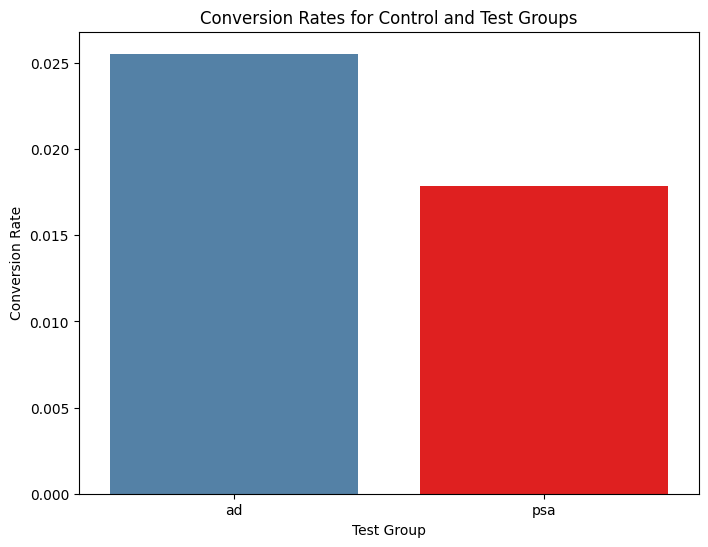

In [78]:
#  conversion rate by control and test group
conversion_rates = df.groupby('test group')['converted'].mean().reset_index()
conversion_rates.columns = ['Test Group', 'Conversion Rate']
plt.figure(figsize=(8, 6))
sns.barplot(x='Test Group', y='Conversion Rate', data=conversion_rates,hue='Test Group',                
    palette=['steelblue', 'red'],)
plt.title('Conversion Rates for Control and Test Groups')
plt.xlabel('Test Group')
plt.ylabel('Conversion Rate')
plt.show()

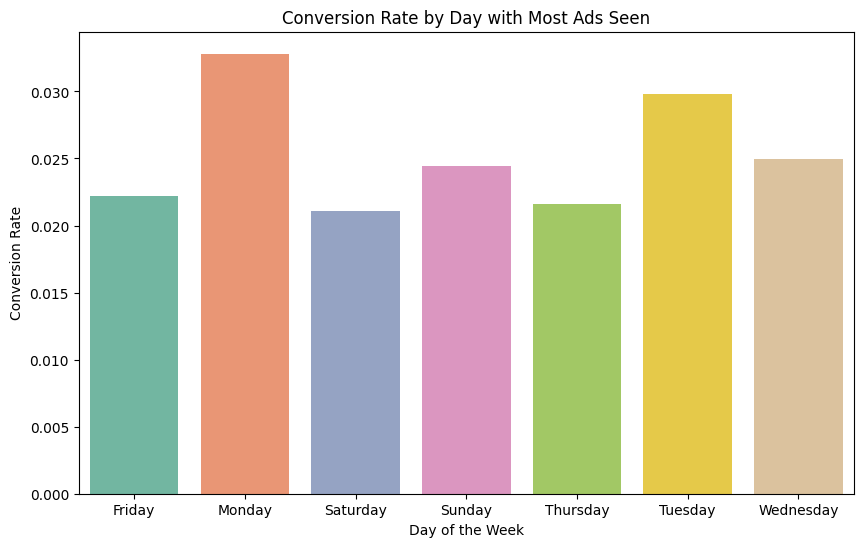

In [81]:
#conversion Rate by Most Ads Day
day_conversion_rate = df.groupby('most ads day')['converted'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=day_conversion_rate, x='most ads day', y='converted',hue='most ads day',palette='Set2')
plt.title('Conversion Rate by Day with Most Ads Seen')
plt.xlabel('Day of the Week')
plt.ylabel('Conversion Rate')
plt.show()

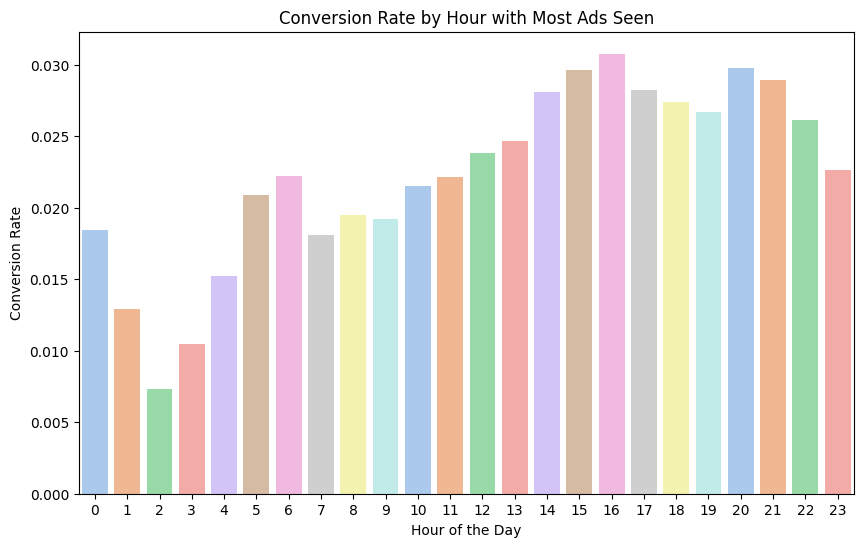

In [89]:
#conversion Rate by Most Ads Hour
hour_conversion_rate = df.groupby('most ads hour')['converted'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=hour_conversion_rate, x='most ads hour', y='converted',palette='pastel')
plt.title('Conversion Rate by Hour with Most Ads Seen')
plt.xlabel('Hour of the Day')
plt.ylabel('Conversion Rate')
plt.show()

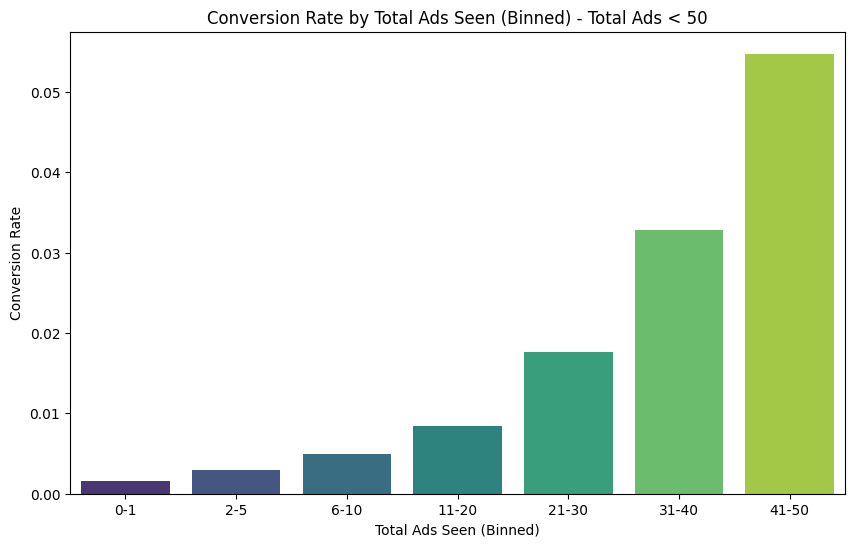

In [91]:
#conversion Rate by Total Ads
ads_conversion_rate_bin = df_subset.groupby('total_ads_bin')['converted'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=ads_conversion_rate_bin, x='total_ads_bin', y='converted',palette='viridis')
plt.title('Conversion Rate by Total Ads Seen (Binned) - Total Ads < 50')
plt.xlabel('Total Ads Seen (Binned)')
plt.ylabel('Conversion Rate')
plt.show()